In [477]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [478]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [479]:
len(words)

32033

In [480]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [481]:
# build the dataset

block_size = 3 # context length
X, Y = [], []
for w in words:

    # print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        # print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

In [482]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [483]:
def build_dataset(words):
    block_size = 3
    X, Y = [], []
    for w in words:

        # print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            # print(''.join(itos[i] for i in context), '--->', itos[ix])
            context = context[1:] + [ix] # crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [484]:
C = torch.randn((27, 10))
W1 = torch.randn(30, 300)
b1 = torch.randn(300)
W2 = torch.randn(300, 27)
b2 = torch.randn(27)
parameters = [C, W1, b1, W2, b2]

In [485]:
sum(p.nelement() for p in parameters)

17697

In [486]:
for p in parameters:
    p.requires_grad = True

In [487]:
# counts = logits.exp()
# prob = counts / counts.sum(1, keepdims = True)
# loss = -prob[torch.arange(32), Y].log().mean()
#loss = F.cross_entropy(logits, Y[ix]) 
# calculates the exact same loss as the above lines
# saves memory, backward and forward pass can be made more efficient

In [488]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [489]:
lri = []
lossi = []
stepi = []

In [501]:
for i in range (50000):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (32,))

    # forward pass
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(emb.shape[0],30) @ W1 + b1) 
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix]) 
    # print(loss.item())

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    # lr = lrs[i]
    lr = 10**-2
    # lr decay by a factor of 10 after multiple uses 
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    # lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())

print(loss.item())

1.7528488636016846


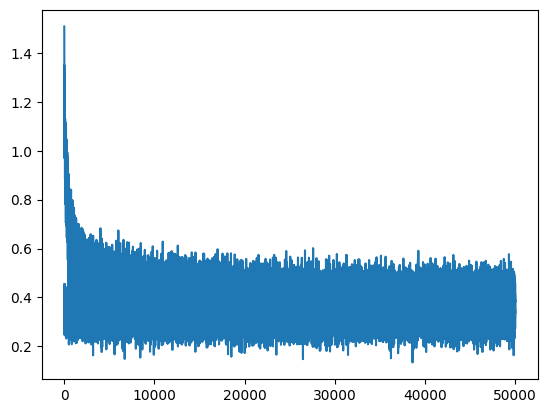

In [496]:
plt.plot(stepi, lossi)

In [502]:
emb = C[Xtr]
h = torch.tanh(emb.view(emb.shape[0],30) @ W1 + b1) 
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr) 
loss

tensor(2.1795, grad_fn=<NllLossBackward0>)

In [503]:
emb = C[Xdev]
h = torch.tanh(emb.view(emb.shape[0],30) @ W1 + b1) 
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev) 
loss

tensor(2.2235, grad_fn=<NllLossBackward0>)

In [505]:
#plt.figure(figsize = (8,8))
#plt.scatter(C[:,0].data, C[:,1].data, s = 200)
#for i in range (C.shape[0]):
#    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha = "center", va = "center", color = 'white')
#plt.grid('minor')

In [508]:
# sample from model
for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim = 1)
        ix = torch.multinomial(probs, num_samples = 1).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))


akiya.
kagd.
jesemani.
traylandri.
telen.
gen.
daaley.
gianny.
jaello.
alexakureshir.
dez.
sar.
chaslijanely.
midgeji.
soityna.
yinstyn.
rami.
tyu.
aelyiah.
wryla.
